In [1]:
# import zipfile

# zip_ref = zipfile.ZipFile("./dogsvscats.zip", "r")
# zip_ref.extractall("./dogsvscats/")
# zip_ref.close()

In [ ]:
import tensorflow as tf

import keras
from keras import Sequential
from keras.layers import (
    Dense,
    Conv2D,
    MaxPooling2D,
    Flatten,
    AvgPool2D,
    Input,
    BatchNormalization,
    Dropout,
)

In [2]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices("GPU")))

Num GPUs Available:  1


In [3]:
# Generators
train_ds = keras.utils.image_dataset_from_directory(
    directory="./dogsvscats/train/",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256),
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory="./dogsvscats/test/",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256),
)

Found 20000 files belonging to 2 classes.


I0000 00:00:1771652904.855941    4747 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3830 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050, pci bus id: 0000:10:00.0, compute capability: 8.6


Found 5000 files belonging to 2 classes.


In [4]:
# Normalize
def process(image, label):
    image = tf.cast(image / 255.0, tf.float32)
    return image, label


train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

### Create CNN Model

In [10]:
model = Sequential(
    [
        Input(shape=(256, 256, 3)),
        # Conv_1
        Conv2D(32, kernel_size=(3, 3), padding="valid", activation="relu"),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2), strides=2, padding="valid"),
        # Conv_2
        Conv2D(64, kernel_size=(3, 3), padding="valid", activation="relu"),  # type: ignore
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2), strides=2, padding="valid"),
        # Conv_3
        Conv2D(128, kernel_size=(3, 3), padding="valid", activation="relu"),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2), strides=2, padding="valid"),
        # Flatten
        Flatten(),
        # ANN
        Dense(128, activation="relu"),
        Dropout(0.1),
        Dense(64, activation="relu"),
        Dropout(0.1),
        Dense(1, activation="sigmoid"),
    ]
)

In [11]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [6]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [7]:
history = model.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10


2026-02-21 11:18:39.009287: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f24fc005000 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-21 11:18:39.009368: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050, Compute Capability 8.6
2026-02-21 11:18:39.289719: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-21 11:18:39.549851: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90300
2026-02-21 11:18:39.580337: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-21 11:18:39.580409: I e

  2/625 ━━━━━━━━━━━━━━━━━━━━ 58s 95ms/step - accuracy: 0.5156 - loss: 1.6879   

I0000 00:00:1771652929.716283    6069 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


625/625 ━━━━━━━━━━━━━━━━━━━━ 76s 103ms/step - accuracy: 0.6015 - loss: 0.6563 - val_accuracy: 0.7234 - val_loss: 0.5269
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 98ms/step - accuracy: 0.7632 - loss: 0.4853 - val_accuracy: 0.7816 - val_loss: 0.4690
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 97ms/step - accuracy: 0.8343 - loss: 0.3674 - val_accuracy: 0.8074 - val_loss: 0.4481
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 95ms/step - accuracy: 0.8990 - loss: 0.2361 - val_accuracy: 0.8022 - val_loss: 0.5472
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 97ms/step - accuracy: 0.9510 - loss: 0.1241 - val_accuracy: 0.7928 - val_loss: 0.6851
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 97ms/step - accuracy: 0.9735 - loss: 0.0759 - val_accuracy: 0.7936 - val_loss: 0.8132
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 98ms/step - accuracy: 0.9833 - loss: 0.0523 - val_accuracy: 0.8068 - val_loss: 1.0105
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 97ms/step - accuracy: 0.9874 - loss: 0.0378 - val_accura

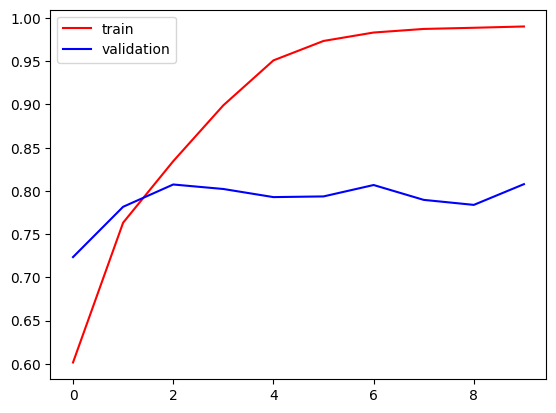

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], color="red", label="train")
plt.plot(history.history["val_accuracy"], color="blue", label="validation")

plt.legend()
plt.show()